In [ ]:
import warnings
warnings.filterwarnings('ignore')
import random
random.seed(0)
import numpy as np
np.random.seed(0)
import tensorflow as tf
tf.random.set_seed(0)
from google.colab.patches import cv2_imshow
from tensorflow.keras import datasets,layers
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from PIL import Image
import os


In [ ]:
fashion_mnist=datasets.fashion_mnist
(train_images,train_labels),(test_images,test_labels)=fashion_mnist.load_data() ## Import the Fashion-MNIST dataset from Keras datasets

In [ ]:
type(train_images) #check the type of train_images

numpy.ndarray

In [ ]:
type(train_labels) #check the type of train_labels

numpy.ndarray

In [ ]:
train_images.shape #chesck the shape of train images

(60000, 28, 28)

In [ ]:
train_images[0] # Access the first image from the training dataset
print(train_images[0]) # Print the pixel values of the first training image


[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

In [ ]:
train_labels[0] # Access the label of the first training image
print(train_labels[0]) # Print the label of the first training image

9


In [ ]:
cv2_imshow(train_images[0]) #Display the first training image by using OpenCV's imshow function

In [ ]:
cv2_imshow(train_images[1])

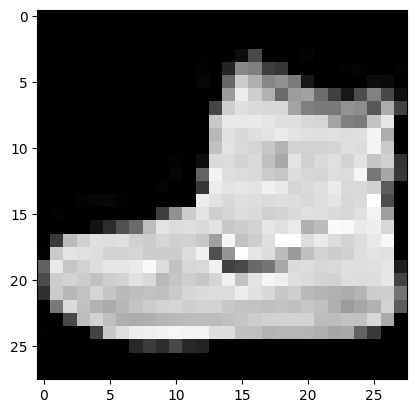

In [ ]:
plt.imshow(train_images[0],cmap='grey') # Display image from the dataset
plt.show()

In [ ]:
class_name=['T-shirt','Trouser','Pullover','Dress','Coat','Sandal',
            'Shirt','Sneaker','Bag','Ankel','Boot'] # different class for differnt images

In [ ]:
train_images,test_images=train_images/255.0,test_images/255.0 # Normalize pixel value between 0 to 1

In [ ]:
train_images=train_images.reshape((train_images.shape[0],28,28,1)) # Reshape training images to add a channel dimension
test_images=test_images.reshape((test_images.shape[0],28,28,1)) # Reshape testing images to add a channel dimension

In [ ]:
model = models.Sequential() # create a sequential model(layer added another after another)
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1))) # First convolutuonal layer of 32 filters
model.add(layers.MaxPooling2D((2,2))) # First Maxpooling Layer
model.add(layers.Conv2D(64,(3,3),activation='relu')) # Second Convolutional layer of 64 filters
model.add(layers.MaxPooling2D((2,2))) # Second Max Pooling layer
model.add(layers.Conv2D(64,(3,3),activation='relu')) # Third Convolutional layer

In [ ]:
model.add(layers.Flatten()) # Flatten the 3D feature maps into a 1D vector
model.add(layers.Dense(64,activation='relu')) # Fully connected (Dense) hidden layer
model.add(layers.Dense(10)) # Output layer

In [ ]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy']) # compile and train the model

In [ ]:
history=model.fit(train_images,train_labels,epochs=10,
                  validation_data=(test_images,test_labels)) #model.fit train the model on the training data on each epoch

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 26ms/step - accuracy: 0.7489 - loss: 0.6951 - val_accuracy: 0.8695 - val_loss: 0.3626
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step - accuracy: 0.8779 - loss: 0.3357 - val_accuracy: 0.8835 - val_loss: 0.3260
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.8975 - loss: 0.2822 - val_accuracy: 0.8895 - val_loss: 0.3024
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9085 - loss: 0.2481 - val_accuracy: 0.8976 - val_loss: 0.2817
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 26ms/step - accuracy: 0.9184 - loss: 0.2195 - val_accuracy: 0.8994 - val_loss: 0.2864
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.9265 - loss: 0.1969 - val_accuracy: 0.9002 - val_loss: 0.2927
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9340 - loss: 0.1760 - val_accuracy: 0.9014 - val_loss: 0.2928
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.9412 -

In [ ]:
test_loss,test_acc=model.evaluate(test_images,test_labels,verbose=2) ## Evaluate the trained model on test data
print("accuracy_test:",test_acc) ## Print the test accuracy

313/313 - 2s - 7ms/step - accuracy: 0.9029 - loss: 0.3283
accuracy_test: 0.902899980545044


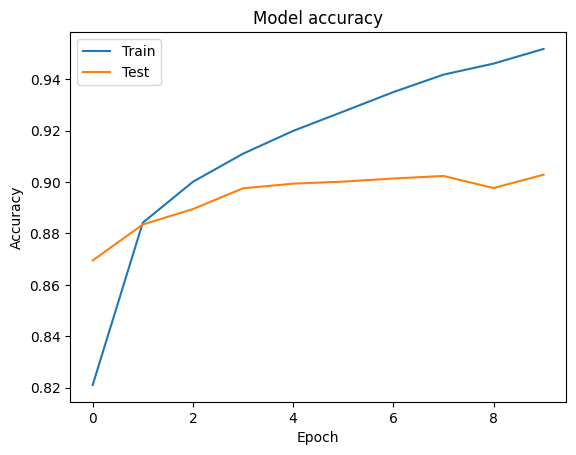

In [ ]:
plt.plot(history.history['accuracy'])   # Training accuracy plot
plt.plot(history.history['val_accuracy'])  # Validation accuracy plot
plt.title('Model accuracy') # Graph title
plt.ylabel('Accuracy') # Y-axis label
plt.xlabel('Epoch') # X-axis label
plt.legend(['Train','Test'],loc='upper left') # Legend for lines
plt.show() # Display the plot

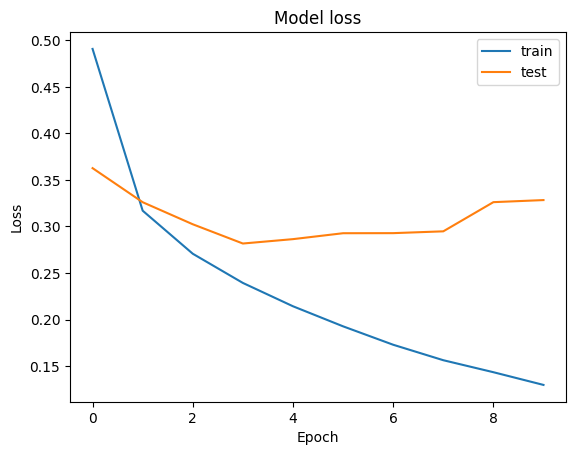

In [ ]:
plt.plot(history.history['loss']) # Training loss plot
plt.plot(history.history['val_loss']) # Validation loss plot
plt.title('Model loss') # Graph title
plt.ylabel('Loss')# Y-axis label
plt.xlabel('Epoch')  # X-axis label
plt.legend(['train','test'],loc='upper right')  # Legend for lines
plt.show()  # Show the plot

In [ ]:
model.save('train_fashion_mnist_model.h5')


In [ ]:
work_dir = os.getcwd()
model_path=f"{work_dir}/train_fashion_mnist_model.h5"
model=tf.keras.models.load_model(model_path)

In [ ]:
class_name=['T-shirt','Trouser','Pullover','Dress','Coat','Sandal',
            'Shirt','Sneaker','Bag','Ankel','Boot'] # different class for differnt images

In [ ]:
from matplotlib import image
def prepocess_image(image):
  img=Image.open(image)
  img=img.resize((28,28)) # Resize expects a tuple
  img=img.convert('L') #convert to greyscale
  img_array=np.array(img)/255
  img_array=img_array.reshape(1,28,28,1) # Corrected: img_array.reshape
  return img_array

In [ ]:
uploaded_image=st.file_uploader("upload_an_image...",type=['jpg','jpeg','png'])

2026-01-28 06:41:43.597 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-28 06:41:43.598 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-28 06:41:43.600 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-28 06:41:43.602 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-28 06:41:43.603 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-28 06:41:43.604 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


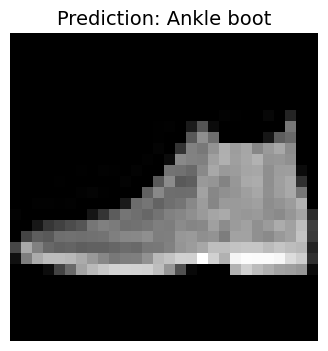

Predicted class: Ankle boot


In [ ]:
# Save a test image temporarily to demonstrate the prediction
plt.imsave('test_image_0.png', test_images[0].reshape(28, 28), cmap='gray')
image_path = 'test_image_0.png'
img_array = prepocess_image(image_path)

# Predict
result = model.predict(img_array)
predicted_class = np.argmax(result)

# Display the image with prediction (fixed indentation and img definition)
plt.figure(figsize=(4,4))
img = Image.open(image_path) # Load image again for display
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {class_name[predicted_class]}", fontsize=14)
plt.show()

# Map numeric class to class name
class_name = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
              'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

prediction = class_name[predicted_class]
print("Predicted class:", prediction)